# PART B – Regression Problem
| admin no. | name           | email contact    |
|-----------|----------------|------------------|
| 9208568W  | Sum Kwok Hoong | sumkh2@gmail.com |
# Cloud Resource Utilization Prediction
## Problem Statement
Cloud service providers need to predict future resource demands to allocate computing resources effectively.   
Predict a continuous variable such as:
- CPU Utilization
- Memory Usage
- Resource Consumption
- Workload Demand
using machine learning regression models.

## Data Exploration

Install the required packages (if needed)
```bash
pip install -r requirements.txt
```

In [1]:
# Loading Libraries for Exploratory Data Analysis
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Path to dataset
database_path = '~/My Drive/ObsidianVaults/NYP/EG272S-Intelligent Services/EG272S_Assignment1/data/cloud_workload_dataset.csv'

# Load dataset
data = pd.read_csv(database_path)

# View data
data.head()

,Job_ID,Submit_Time,Start_Time,End_Time,Requested_CPUs,Used_CPUs,Requested_Memory(MB),Used_Memory(MB),Execution_Time(Seconds),Queue_Wait_Time(Seconds),User_ID,Job_Type,Priority_Level,Node_Count,Interarrival_Time
0,JOB_00001,2024-02-28 04:50:00,2024-02-28 04:57:34,2024-02-28 05:24:07,2,1,27709,25052,1593.205497,454,User_79,batch,high,2,20
1,JOB_00002,2024-01-11 03:12:00,2024-01-11 03:21:15,2024-01-11 03:28:29,2,1,9991,9144,434.744886,555,User_6,GPU,medium,1,10
2,JOB_00003,2024-01-03 06:38:00,2024-01-03 06:46:10,2024-01-03 06:50:28,1,1,7792,7115,258.858481,490,User_73,interactive,medium,1,29
3,JOB_00004,2024-03-08 11:56:00,2024-03-08 12:00:26,2024-03-08 12:14:15,2,1,18860,16838,829.640637,266,User_83,interactive,low,2,3
4,JOB_00005,2024-01-26 00:48:00,2024-01-26 00:49:34,2024-01-26 01:08:23,2,1,19089,18499,1129.775829,94,User_87,batch,medium,1,9


In [3]:
# Reviewing data columns against the data dictionary
# to develop a preliminary understanding of the data and
# note the columns with missing values.

# Remove IDs columns
data = data.drop(['Job_ID', 'User_ID'], axis=1)
data.info()

# Count of missing values for variables with missing values
for col in data.columns:
  if data[col].isnull().sum() > 0:
    print(f'{col} has {data[col].isnull().sum()} missing values')

<class 'pandas.DataFrame'>
RangeIndex: 3562 entries, 0 to 3561
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Submit_Time               3562 non-null   str    
 1   Start_Time                3562 non-null   str    
 2   End_Time                  3562 non-null   str    
 3   Requested_CPUs            3562 non-null   int64  
 4   Used_CPUs                 3562 non-null   int64  
 5   Requested_Memory(MB)      3562 non-null   int64  
 6   Used_Memory(MB)           3562 non-null   int64  
 7   Execution_Time(Seconds)   3562 non-null   float64
 8   Queue_Wait_Time(Seconds)  3562 non-null   int64  
 9   Job_Type                  3562 non-null   str    
 10  Priority_Level            3562 non-null   str    
 11  Node_Count                3562 non-null   int64  
 12  Interarrival_Time         3562 non-null   int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 361.9 KB


### Feature Engineering - TimeOfDay
For a Regression problem, instead of time series forecasting, features such as `Submit_Time`, `Start_Time` and `End_Time` need to extract meaningful features.


In [4]:
# Create Day of week from `Submit_Time`
data['Submit_Time'] = pd.to_datetime(data['Submit_Time'], format='%Y-%m-%d %H:%M:%S')

# Sunday = 0, Monday = 1, ..., Saturday = 6
data['day_of_week'] = (data['Submit_Time'].dt.dayofweek + 1) % 7

# Convert day of week to categorical variable
data['day_of_week'] = data['day_of_week'].astype(str)


`Execution_Time(Second)` is equivalent to the duration between `Start_Time` and `End_Time`, both `Start_Time` and `End_Time` to be excluded.

In [5]:
# Drop `Submit_Time`, `Start_Time` and `End_Time`
data = data.drop(['Submit_Time', 'Start_Time', 'End_Time'], axis=1)

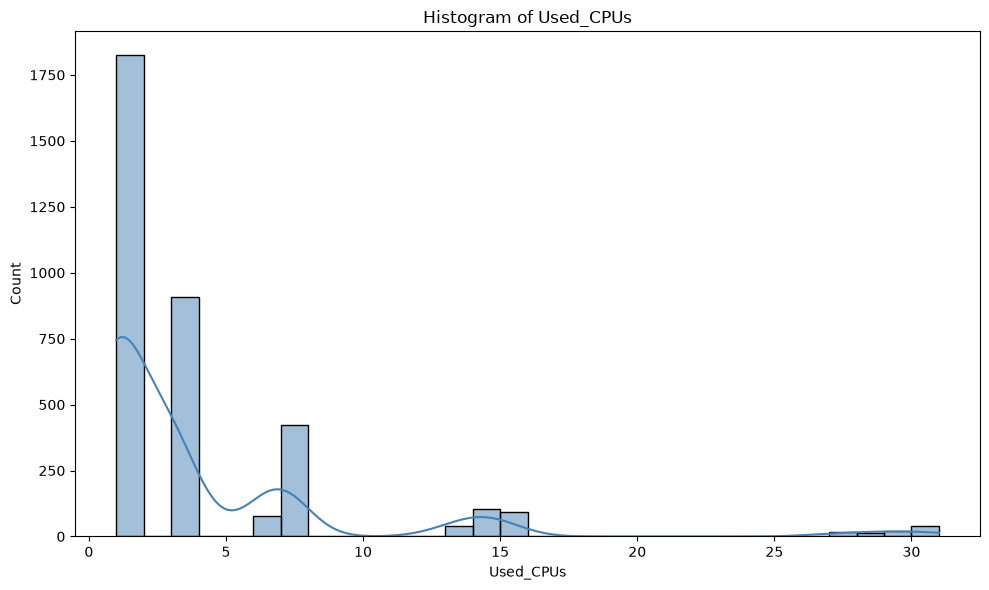

In [6]:
# Plot Histogram for `Used_CPU`
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Used_CPUs', bins=30, kde=True, color='steelblue')
plt.title('Histogram of Used_CPUs')
plt.xlabel('Used_CPUs')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

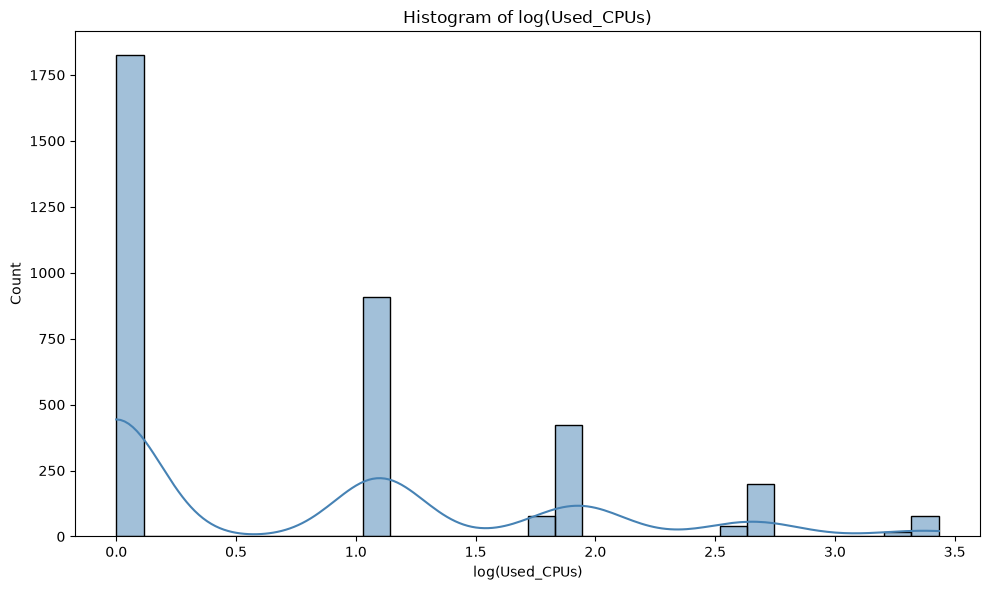

In [7]:
# Plot histogram of the log-transformed values
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x=np.log(data['Used_CPUs']), bins=30, kde=True, color='steelblue')
plt.title('Histogram of log(Used_CPUs)')
plt.xlabel('log(Used_CPUs)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

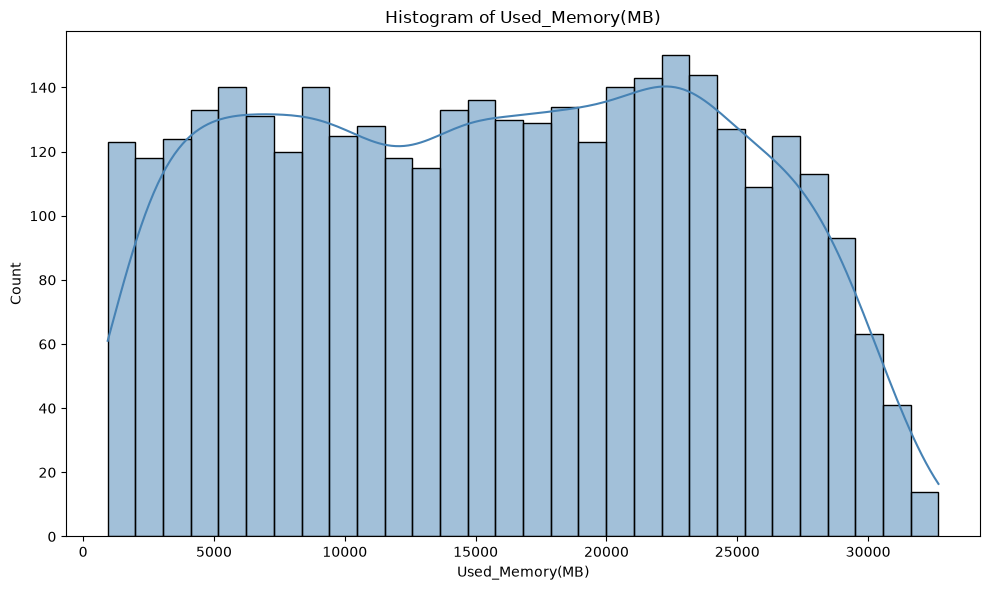

In [8]:
# Plot Histogram for `Used_Memory(MB)`
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Used_Memory(MB)', bins=30, kde=True, color='steelblue')
plt.title('Histogram of Used_Memory(MB)')
plt.xlabel('Used_Memory(MB)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

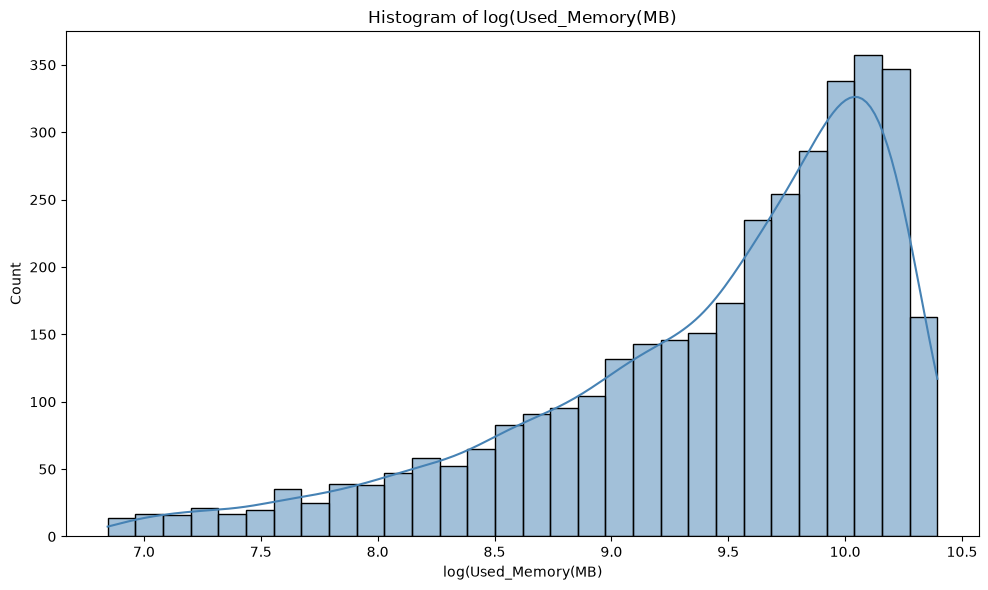

In [9]:
# Plot histogram of the log-transformed values
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x=np.log(data['Used_Memory(MB)']), bins=30, kde=True, color='steelblue')
plt.title('Histogram of log(Used_Memory(MB)')
plt.xlabel('log(Used_Memory(MB)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Choice of Target Variable -> **Used_Memory(MB)**
For the objective to predict future resource demand, I have choose to use the dataset to predict the target variable of `Used__Memory(MB)`. The variable `Requested__Memory(MB)` which is highly proportional and related to the target variable will be dropped. `Requested__Memory(MB)` is selected is also due to the distribution of the log of `Requested__Memory(MB)` showing a characteristic of normal distribution.  

In [10]:
# Get list of numerical variables
num_cols = []
for col in data.columns:
    if data[col].dtype != 'str':
        num_cols.append(col)

print(f'There are {len(num_cols)} numerical variables:')
print(num_cols) 

There are 8 numerical variables:
['Requested_CPUs', 'Used_CPUs', 'Requested_Memory(MB)', 'Used_Memory(MB)', 'Execution_Time(Seconds)', 'Queue_Wait_Time(Seconds)', 'Node_Count', 'Interarrival_Time']


In [11]:
# Descriptive Statistics for all numerical variables
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Requested_CPUs,3562.0,4.863841,5.866074,1.000000,2.000000,2.000000,4.000000,32.00000
Used_CPUs,3562.0,3.940202,5.424788,1.000000,1.000000,1.000000,3.000000,31.00000
Requested_Memory(MB),3562.0,16915.217013,9078.513041,1036.000000,8950.500000,17121.000000,24680.250000,32765.00000
Used_Memory(MB),3562.0,15636.411005,8423.948503,939.000000,8352.750000,15716.500000,22779.750000,32689.00000
Execution_Time(Seconds),3562.0,1104.028749,549.530835,81.605762,687.214229,1046.839066,1457.295271,3451.77663
Queue_Wait_Time(Seconds),3562.0,333.038462,155.648747,60.000000,198.000000,334.000000,465.000000,599.00000
Node_Count,3562.0,3.181640,3.563027,1.000000,1.000000,2.000000,4.000000,16.00000
Interarrival_Time,3562.0,9.927007,10.383938,0.000000,3.000000,7.000000,13.000000,89.00000


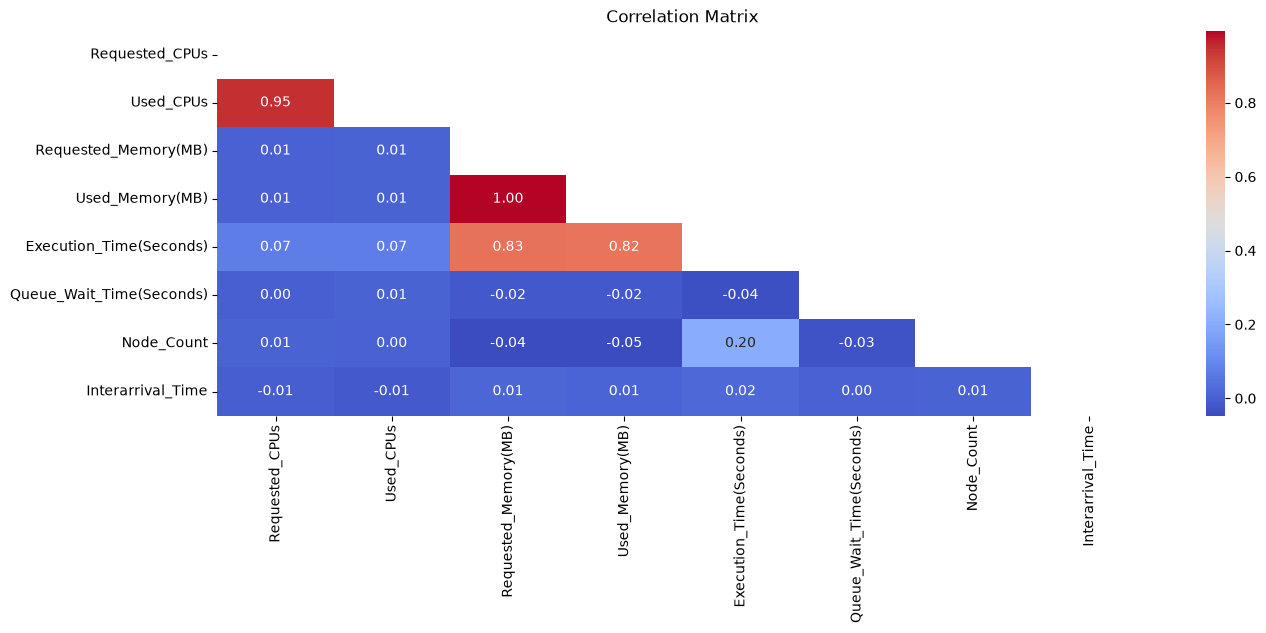

In [12]:
# Plotting Correlation Analysis Heatmaps
# Correlation matrix
data_num = data[num_cols]

plt.figure(figsize=(15, 5))
corr_matrix = data_num.corr(method='spearman')  # Exclude target from correlation matrix calculation

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm')
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.title('Correlation Matrix')
plt.show()

As expected, `Requested_CPUs` and `Requested_Memory` is highly correlated with `Used_CPUs` and `Used_Memory`. For the business problem to predict the demand on computing resources, `Requested_CPUs` and `Requested_Memory` are dropped.

`Execution_Time` is also observed to be highly correlated to `Requested_Memory` and `Used_Memory`. For the business problem to predict the demand on computing resources, when higher resources are requested (such as memory), it is expected that it will takes longer `Execution_Time` to provision the resources.

In [13]:
# Drop `Requested_CPUs` and `Requested_Memory`
data = data.drop(['Requested_CPUs', 'Requested_Memory(MB)'], axis = 1)

In [14]:
# Update list of numerical variables
num_cols = []
for col in data.columns:
    if data[col].dtype != 'str':
        num_cols.append(col)

print(f'There are {len(num_cols)} numerical variables:')
print(num_cols) 

There are 6 numerical variables:
['Used_CPUs', 'Used_Memory(MB)', 'Execution_Time(Seconds)', 'Queue_Wait_Time(Seconds)', 'Node_Count', 'Interarrival_Time']


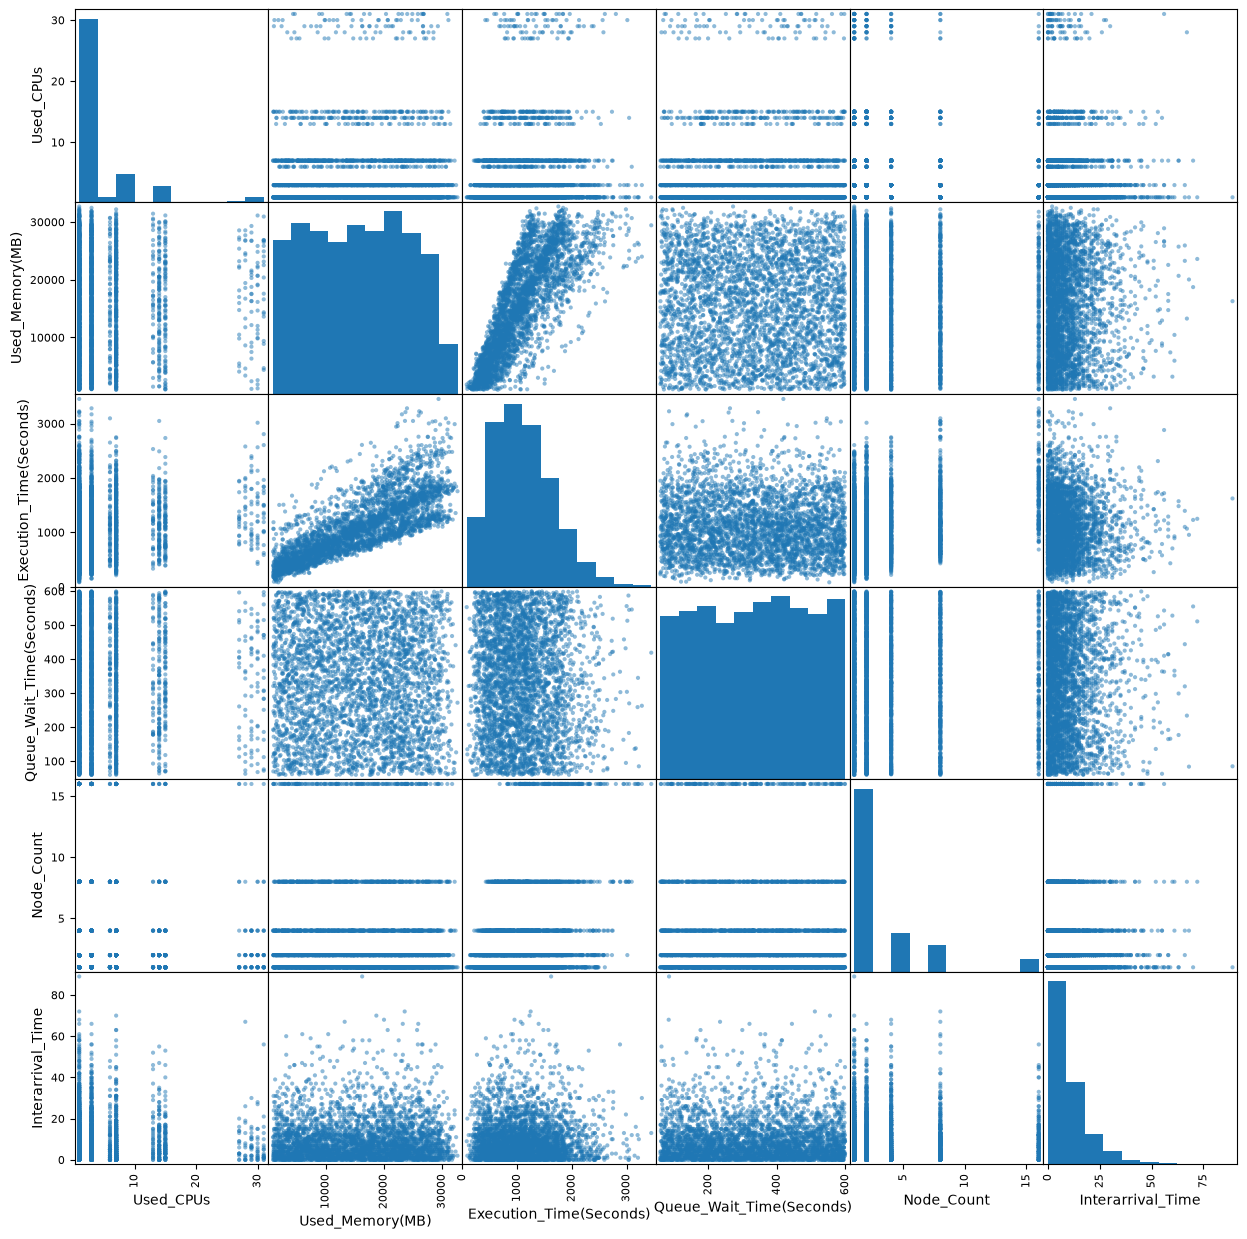

                          Used_CPUs  Used_Memory(MB)  Execution_Time(Seconds)  \
Used_CPUs                  1.000000         0.030620                 0.102693   
Used_Memory(MB)            0.030620         1.000000                 0.779333   
Execution_Time(Seconds)    0.102693         0.779333                 1.000000   
Queue_Wait_Time(Seconds)   0.005088        -0.018157                -0.040228   
Node_Count                -0.000978        -0.036922                 0.297630   
Interarrival_Time         -0.011947         0.019386                 0.019291   

                          Queue_Wait_Time(Seconds)  Node_Count  \
Used_CPUs                                 0.005088   -0.000978   
Used_Memory(MB)                          -0.018157   -0.036922   
Execution_Time(Seconds)                  -0.040228    0.297630   
Queue_Wait_Time(Seconds)                  1.000000   -0.025801   
Node_Count                               -0.025801    1.000000   
Interarrival_Time                   

In [15]:
# Plotting scatter matrix and analyse correlation
from pandas.plotting import scatter_matrix
scatter_matrix(data, figsize=(15,15))
plt.show()

print(data[num_cols].corr())

In [16]:
# Define function to plot violin plots for numerical variables against categorical variables
def plot_violin_plots(df, num_cols, cat_cols, resource_var):
  if not cat_cols:
      print('No categorical columns found for violin plots.')
      return

  for cat in cat_cols:
    order_list = sorted(df[cat].dropna().unique())
    fig, axes = plt.subplots(nrows=len(resource_var), ncols=1, figsize=(12, len(resource_var) * 5), squeeze=False)
    axes = axes.flatten()

    for i, res in enumerate(resource_var):
        sns.violinplot(data=df, x=cat, y=res, ax=axes[i], order=order_list, inner='quart')
        axes[i].set_title(f'{res} by {cat}')
        axes[i].tick_params(axis='x', rotation=45)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


In [17]:
# Get list of categorical variables
data.info()

cat_cols = data.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

print(f'There are {len(cat_cols)} categorical variables:')
print(cat_cols) 

<class 'pandas.DataFrame'>
RangeIndex: 3562 entries, 0 to 3561
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Used_CPUs                 3562 non-null   int64  
 1   Used_Memory(MB)           3562 non-null   int64  
 2   Execution_Time(Seconds)   3562 non-null   float64
 3   Queue_Wait_Time(Seconds)  3562 non-null   int64  
 4   Job_Type                  3562 non-null   str    
 5   Priority_Level            3562 non-null   str    
 6   Node_Count                3562 non-null   int64  
 7   Interarrival_Time         3562 non-null   int64  
 8   day_of_week               3562 non-null   str    
dtypes: float64(1), int64(5), str(3)
memory usage: 250.6 KB
There are 3 categorical variables:
['Job_Type', 'Priority_Level', 'day_of_week']


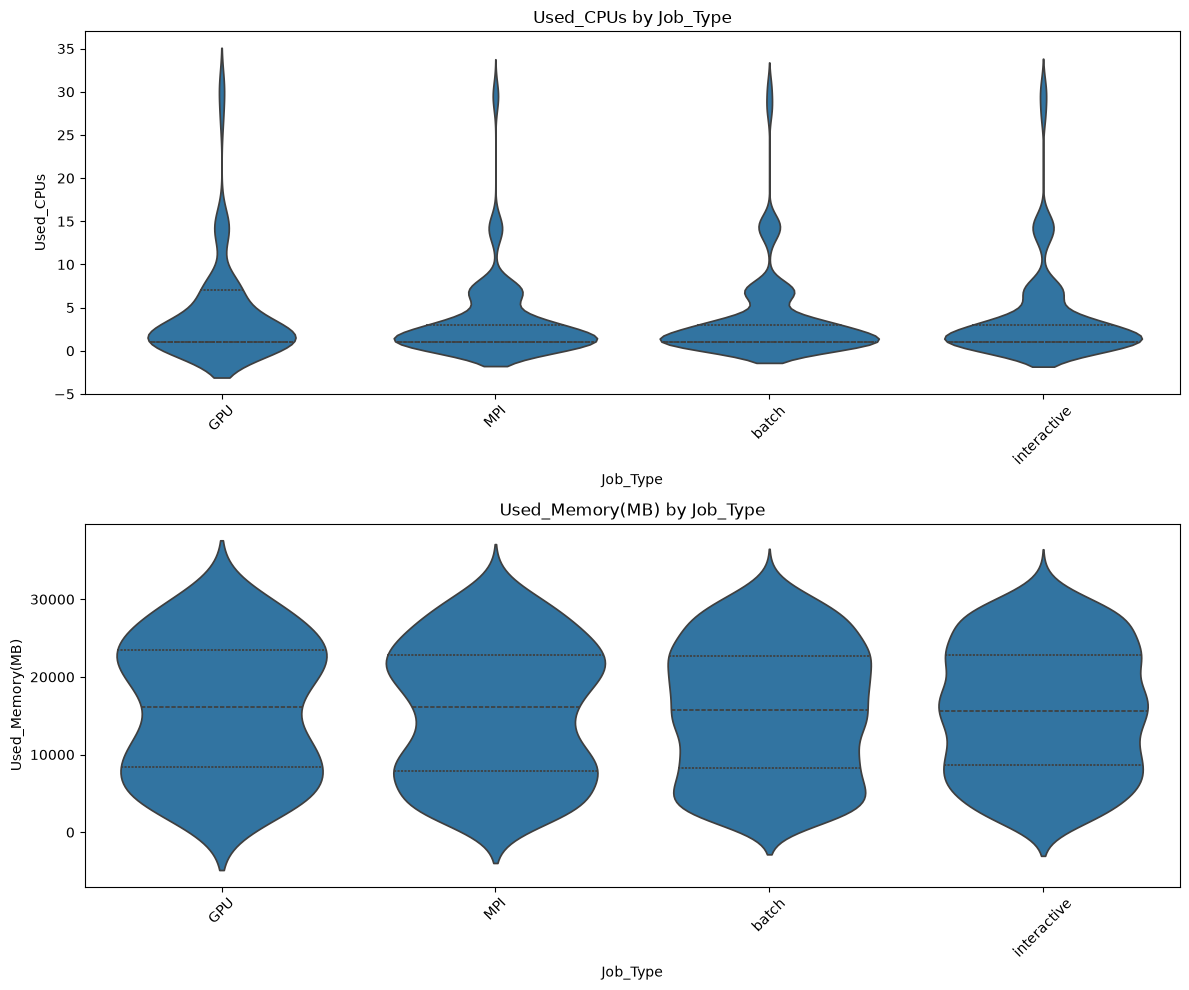

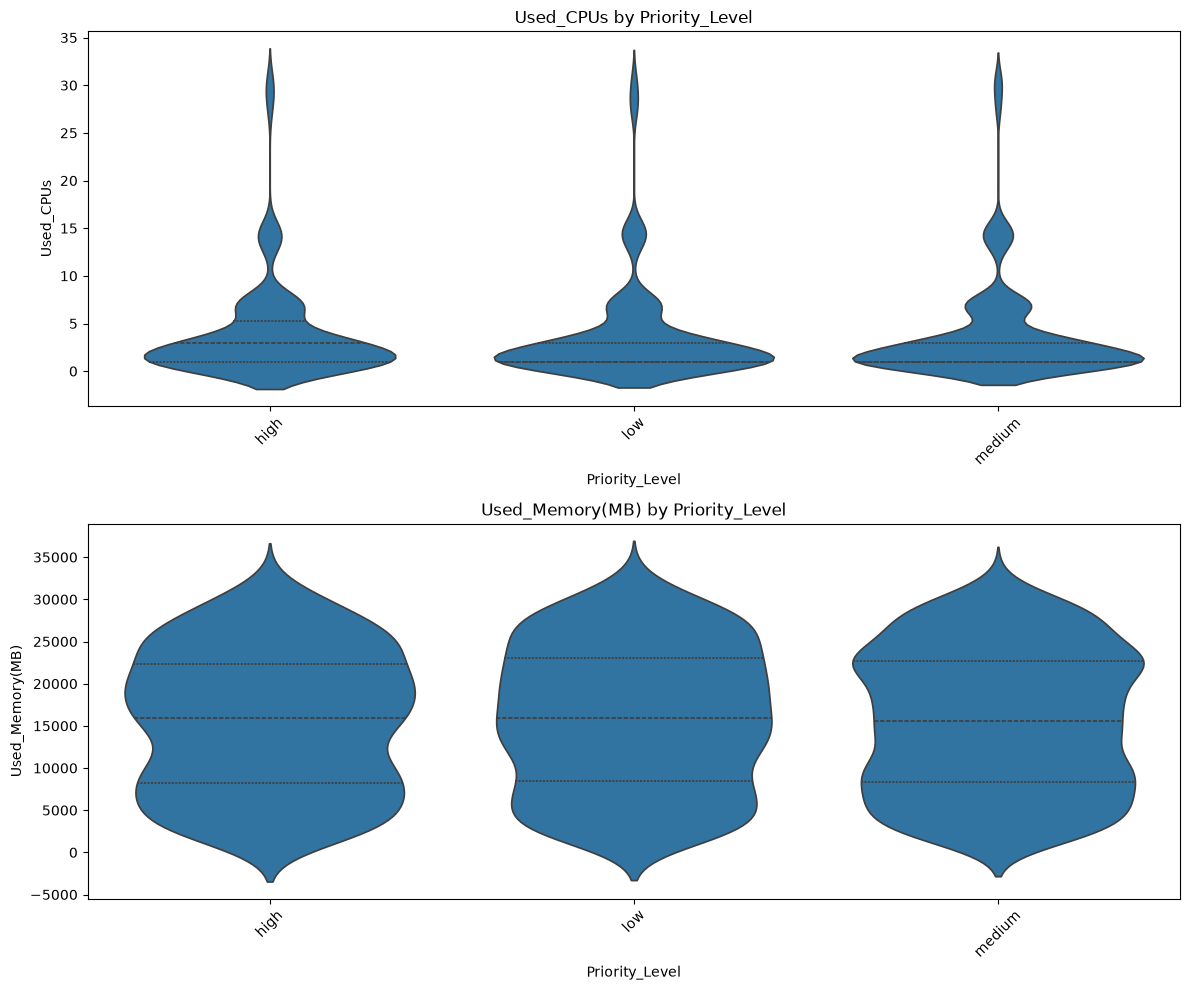

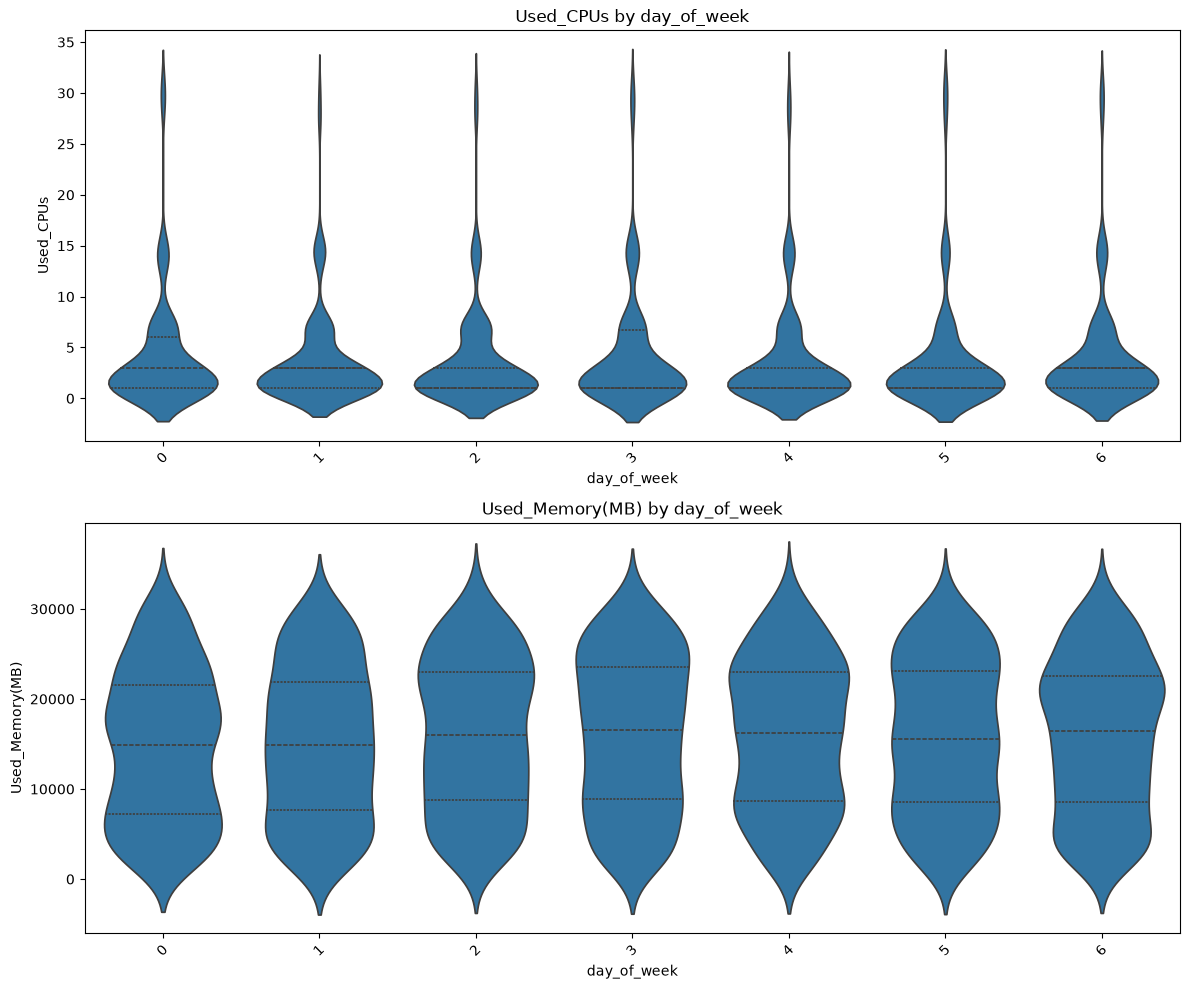

In [18]:
# Plot the Violin Plots
resource_var = ['Used_CPUs', 'Used_Memory(MB)']

plot_violin_plots(data, num_cols, cat_cols, resource_var)

Observed that there is no observable variation in the CPUs and Memory usages across `Job_Type`, `Priority_level` or `day_of_week` 

### Split the data into Train and Test Sets

In [19]:
from sklearn.model_selection import train_test_split

# Separate X and Y sets
X = data.drop(['Used_Memory(MB)'], axis=1)
y = data['Used_Memory(MB)']

# Split the data into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# List out the X_train variables
X_train.info()

<class 'pandas.DataFrame'>
Index: 2849 entries, 1200 to 3174
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Used_CPUs                 2849 non-null   int64  
 1   Execution_Time(Seconds)   2849 non-null   float64
 2   Queue_Wait_Time(Seconds)  2849 non-null   int64  
 3   Job_Type                  2849 non-null   str    
 4   Priority_Level            2849 non-null   str    
 5   Node_Count                2849 non-null   int64  
 6   Interarrival_Time         2849 non-null   int64  
 7   day_of_week               2849 non-null   str    
dtypes: float64(1), int64(4), str(3)
memory usage: 200.3 KB


### Model Training

In [20]:
# Load Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    r2_score, 
    mean_absolute_error, 
    mean_squared_error, 
    mean_absolute_percentage_error
    )

import time
import warnings
import logging
warnings.filterwarnings('ignore')


In [21]:
# Determine the list of numerical features
num_var = X_train.select_dtypes(include=['float64', 'int64']).columns
cat_var = X_train.select_dtypes(include=['str']).columns

# Define the model and respective hyperparameters search space and train the models
model_class = {
    'sgd': SGDRegressor,
    'dtree': DecisionTreeRegressor,
    'random_forest': RandomForestRegressor  # Note: no parentheses
    }

model_params = {
    'sgd': {
        'model__loss': ['squared_error', 'huber'],
        'model__penalty': ['l1', 'l2'], # default is l2
    },
    'dtree': {
        'model__max_depth': [None, 10, 20, 30],
    },
    'random_forest': {
        'model__max_depth': [None, 10, 20, 30],
    },
}

The ‘squared_error’ refers to the ordinary least squares fit. ‘huber’ modifies ‘squared_error’ to focus less on getting outliers correct by switching from squared to linear loss past a distance of epsilon.

### Helper Functions for Model Evaluations

In [22]:
# Define Function to compute evaluation metrices for each model
def compute_metrices(model_data, X_test, y_test, model_name = 'model_name'):

    # Make predictions on the X
    y_pred = model_data.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5   # RMSE = sqrt(MSE)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    # Results Dictionary
    results = {
        'model': model_name,
        'R2': r2,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape
    }

    return results

### Training the Models

In [23]:
# Setup cross validation folds
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Concat X_test with y_test
eval_data = pd.concat([X_test, y_test], axis=1)

In [24]:
# Create an empty list to store the results
results = []
cvfit_results = []
test_metrics_results = []
start_time = time.time()
best_estimators = {}

# Train the models
for model_name, params in model_params.items():
    # Build pipeline from scratch every time they are called.
    # Data preprocessing step with ColumnTransformer
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
        ])
    # Preprocessing for categorical data
    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, num_var),
            ('cat', cat_transformer, cat_var),
        ],
        remainder='passthrough', # Use 'passthrough' for columns not specified
        )

    # Build pipeline for the model
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model_class[model_name]()) # ensure the model is instantiated with ()
    ])

    grid_search = GridSearchCV(pipeline,
                                param_grid = params,
                                cv=cv,
                                scoring='neg_mean_squared_error',
                                verbose=1,
                                return_train_score=True,
                                n_jobs=-1) # Set n_jobs to -1 to use all available cores

    print(f"\nTraining {model_name}...")
    grid_search.fit(X_train, y_train)
    best_estimators[model_name] = grid_search.best_estimator_
    
    # Store the cross-validation results
    cv_results = grid_search.cv_results_
    for i in range(len(cv_results['mean_train_score'])):
        cvfit_results.append({
            'model': model_name,
            'fit_index': i,
            'params': grid_search.best_params_,
            'mean_train_score': cv_results['mean_train_score'][i],
            'mean_validation_score': cv_results['mean_test_score'][i],
        })

    # Store the best model for later use
    results.append({
        'model': model_name,
        'best_params': grid_search.best_params_,
        'best_train_score': grid_search.cv_results_['mean_train_score'][grid_search.best_index_],
        'best_validation_score': grid_search.best_score_,
        'model_data': grid_search.best_estimator_,
    })

    # Compute Evaluation Metrices
    test_metrics = compute_metrices(grid_search.best_estimator_, X_test, y_test, model_name)
    test_metrics_results.append(test_metrics)
    print(test_metrics)

end_time = time.time()
print(f"Total time (training + evaluation): {end_time - start_time:.2f} seconds")


Training sgd...
Fitting 5 folds for each of 4 candidates, totalling 20 fits


{'model': 'sgd', 'R2': 0.9135262680771257, 'MAE': 1832.1626944631198, 'MSE': 6072603.713478744, 'RMSE': 2464.2653496486014, 'MAPE': 0.24519286270931887}

Training dtree...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
{'model': 'dtree', 'R2': 0.9436487498449547, 'MAE': 1512.5662200837507, 'MSE': 3957257.3467270196, 'RMSE': 1989.2856372896829, 'MAPE': 0.1523874330782034}

Training random_forest...
Fitting 5 folds for each of 4 candidates, totalling 20 fits


{'model': 'random_forest', 'R2': 0.961900078946212, 'MAE': 1324.5985896903783, 'MSE': 2675560.738847655, 'RMSE': 1635.714137264716, 'MAPE': 0.13527775958176588}
Total time (training + evaluation): 4.27 seconds


### Model Evaluations

In [25]:
# Convert cv_results to DataFrame
cvfit_results_df = pd.DataFrame(cvfit_results)
cvfit_results_df = cvfit_results_df.sort_values(by='mean_validation_score', ascending=False)

# Convert results to DataFrame
all_results_df = pd.DataFrame(results)
all_results_df = all_results_df.sort_values(by='best_validation_score', ascending=False).reset_index(drop=True)

all_results_df[['model', 'best_train_score', 'best_validation_score']]

,model,best_train_score,best_validation_score
0,random_forest,-4.163377e+05,-2.971331e+06
1,dtree,-1.074547e+06,-4.656698e+06
2,sgd,-5.798743e+06,-5.894572e+06


In [26]:
# Print Results
results_df = pd.DataFrame(test_metrics_results)
results_df = results_df.sort_values(by='R2', ascending=False).reset_index(drop=True)
results_df

,model,R2,MAE,MSE,RMSE,MAPE
0,random_forest,0.961900,1324.598590,2.675561e+06,1635.714137,0.135278
1,dtree,0.943649,1512.566220,3.957257e+06,1989.285637,0.152387
2,sgd,0.913526,1832.162694,6.072604e+06,2464.265350,0.245193


In [27]:
print('\n--------- Best Model (After Evaluation with Test Data) ---------\n')

selected_model = results_df.iloc[0]['model']

# Print the best model
print (f"Best Model: {results_df.iloc[0]['model']}")
print (f"Best Parameters: {all_results_df.iloc[0]['best_params']}")

print('\n------------------------------------\n')

# Save the best model
best_model_data = all_results_df.iloc[0]['model_data']


--------- Best Model (After Evaluation with Test Data) ---------

Best Model: random_forest
Best Parameters: {'model__max_depth': 20}

------------------------------------



Random Forest is the best model as it gives the best RMSE as well as R2.

#### Visual Evaluation of Best Estimator Predictions

In [28]:
# Define a function for Visual Evaluation

def visual_evaluation(X_test, y_test, y_pred):

  # Set up figure size
  plt.figure(figsize=(12, 6))

  # Visual Evaluation of Predictions
  plt.subplot(1,2,1) # row 1, col 2 index 1
  plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
  plt.xlabel('Actual Prices')
  plt.ylabel('Predicted Prices')
  plt.title('Actual Prices vs. Predicted Prices')

  plt.tight_layout()

  plt.show()


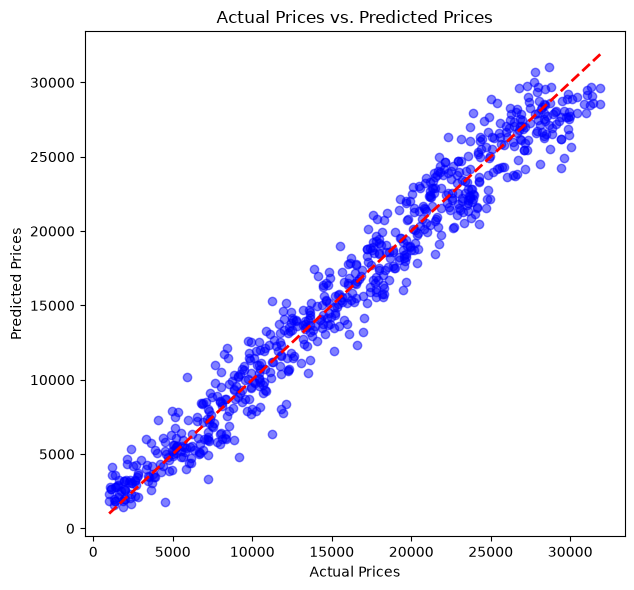

In [29]:
# Get Predictions
best_model = best_estimators['random_forest']

y_pred = best_model.predict(X_test)

# Visual Evaluation
visual_evaluation(X_test, y_test, y_pred)


#### Residual Plot

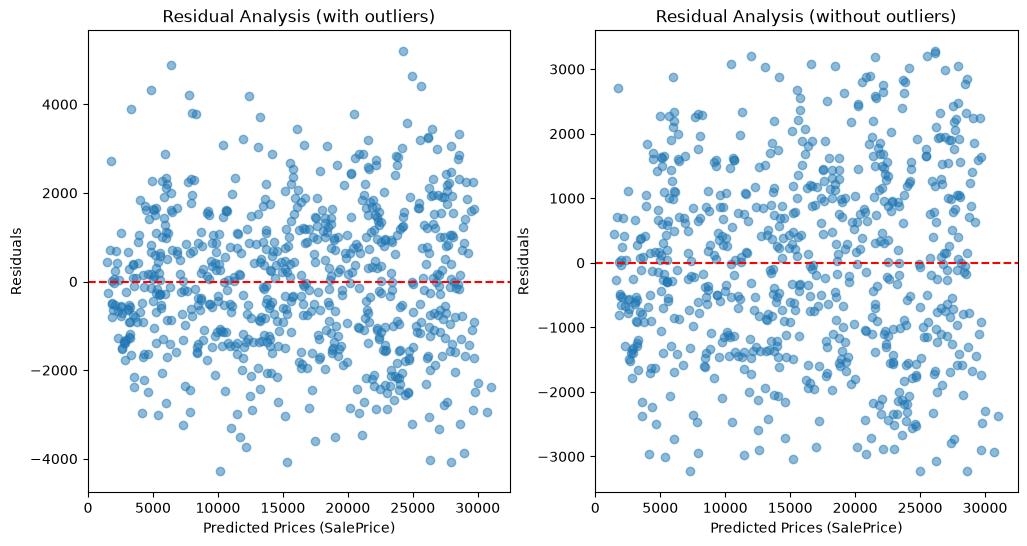

<Figure size 640x480 with 0 Axes>

In [30]:
# Residual Analysis
residuals = y_test - y_pred

# Identifying Outliers in the residuals
mean_res = np.mean(residuals)
std_dev_res = np.std(residuals)
outliers = np.abs(residuals - mean_res) > 2 * std_dev_res

# Set up figure size
plt.figure(figsize=(12, 6))

# Residual Plot (with outliers)
plt.subplot(1,2,1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Prices (SalePrice)')
plt.ylabel('Residuals')
plt.title('Residual Analysis (with outliers)')

# Residual Plot (without outliers)
plt.subplot(1,2,2)
plt.scatter(y_pred[~outliers], residuals[~outliers], alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Prices (SalePrice)')
plt.ylabel('Residuals')
plt.title('Residual Analysis (without outliers)')
plt.show()


plt.tight_layout()
plt.show()


I do not observe any noticiable pattern or distribution of the residuals alongthe zero line that may indicate any information not captured by the model.

### Features Coeficients for the Model

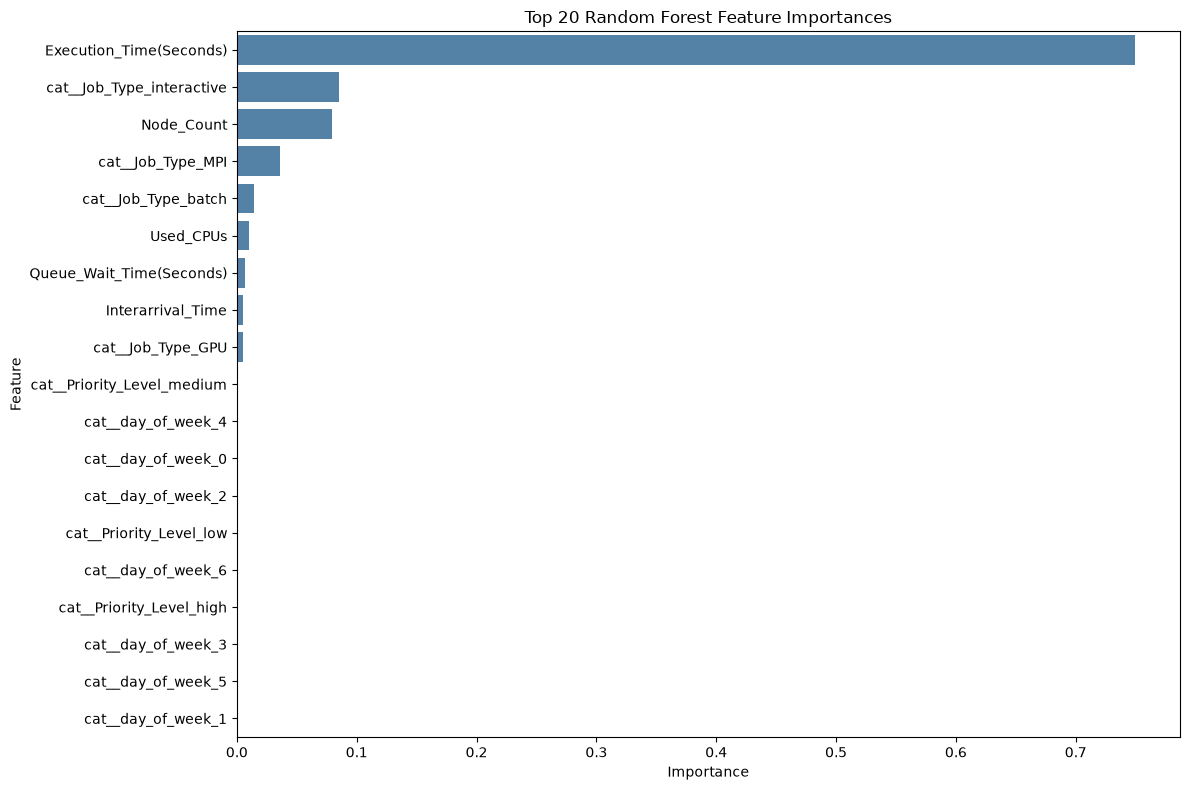

In [31]:
# Get the fitted pipeline
model_pipeline = all_results_df.loc[
    all_results_df['model'] == selected_model, 'model_data'
].iloc[0]

# Extract transformed feature names from the preprocessor
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get random forest feature importances
importances = model_pipeline.named_steps['model'].feature_importances_

# Build a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Remove the preprocessing prefixes
feature_importance_df['Feature'] = feature_importance_df['Feature'].str.replace('num__', '', regex=False)
feature_importance_df['Feature'] = feature_importance_df['Feature'].str.replace('remainder__', '', regex=False)

# Sort and show top features
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

top_n = 20
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_features, x='Importance', y='Feature', color='steelblue')
plt.title(f'Top {top_n} Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()